<a href="https://colab.research.google.com/github/DeepthiManthapuram/Deep_Learning/blob/main/AI_Contract_Intelligence_System_using_Self_Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AI Contract Intelligence System using Self-Attention

Problem Statement
A legal company receives thousands of contracts every month.
A contract may contain:
Payment Terms
Renewal Clauses
Termination Conditions
Confidentiality Agreements
Liability Clauses
Lawyers spend hours reading long contracts.
The company wants an AI-powered system that:
Understands contract clauses
Identifies important sections
Highlights critical legal terms
Explains why a clause is important using Attention Scores
You are hired as an AI Engineer to build a Self-Attention-based Contract Intelligence System.
Why Self-Attention?
Consider:
The agreement shall automatically renew for
one additional year unless either party provides
written notice at least 60 days before expiration.
Question:
What words are most important for understanding renewal?
Self-Attention should focus on:
renew
additional year
60 days
expiration
Students can visualize this.


# **Task 1 – Dataset Analysis**
Perform EDA:
Number of contracts
Average contract length
Most common clause types
Longest contract
Shortest contract
Visualize:
Word count distribution
Clause category distribution

Using Colab cache for faster access to the 'bbc-fulltext-and-category' dataset.
Dataset Path: /kaggle/input/bbc-fulltext-and-category
bbc-text.csv

Dataset Shape: (2225, 2)

Columns:
Index(['category', 'text'], dtype='object')

First 5 Rows:
        category                                               text
0           tech  tv future in the hands of viewers with home th...
1       business  worldcom boss  left books alone  former worldc...
2          sport  tigers wary of farrell  gamble  leicester say ...
3          sport  yeading face newcastle in fa cup premiership s...
4  entertainment  ocean s twelve raids box office ocean s twelve...

========== DATASET STATISTICS ==========
Number of Articles: 2225
Average Length: 390.3 words
Longest Article: 4492 words
Shortest Article: 90 words

========== CATEGORY DISTRIBUTION ==========
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

Longest Articl

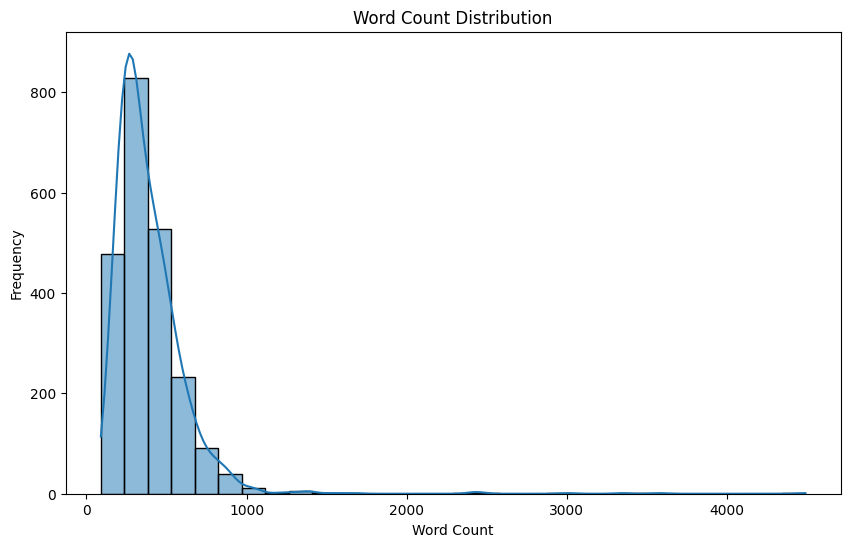

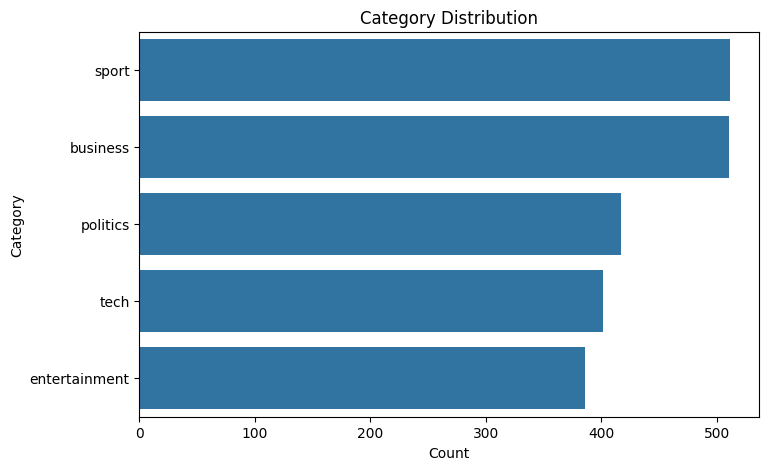


========== WORD COUNT SUMMARY ==========
count    2225.000000
mean      390.295281
std       241.753128
min        90.000000
25%       250.000000
50%       337.000000
75%       479.000000
max      4492.000000
Name: word_count, dtype: float64

========== TOP CATEGORIES ==========
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


In [16]:
# ==========================================
# AI Contract Intelligence System
# Task 1 - Exploratory Data Analysis (EDA)
# Using BBC Full Text Dataset
# ==========================================

import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# -----------------------------
# Download Dataset
# -----------------------------

path = kagglehub.dataset_download(
    "yufengdev/bbc-fulltext-and-category"
)

print("Dataset Path:", path)

# -----------------------------
# Find Dataset File
# -----------------------------

for file in os.listdir(path):
    print(file)

# Replace filename if different
csv_file = os.path.join(path, "bbc-text.csv")

df = pd.read_csv(csv_file)

# -----------------------------
# Basic Information
# -----------------------------

print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

# -----------------------------
# Article Length Analysis
# -----------------------------

df["word_count"] = df["text"].astype(str).apply(
    lambda x: len(x.split())
)

num_articles = len(df)
avg_length = df["word_count"].mean()
longest_article = df["word_count"].max()
shortest_article = df["word_count"].min()

print("\n========== DATASET STATISTICS ==========")

print("Number of Articles:", num_articles)
print("Average Length:", round(avg_length, 2), "words")
print("Longest Article:", longest_article, "words")
print("Shortest Article:", shortest_article, "words")

# -----------------------------
# Category Distribution
# -----------------------------

print("\n========== CATEGORY DISTRIBUTION ==========")

print(df["category"].value_counts())

# -----------------------------
# Longest Article
# -----------------------------

longest_idx = df["word_count"].idxmax()

print("\nLongest Article Category:")
print(df.loc[longest_idx, "category"])

# -----------------------------
# Shortest Article
# -----------------------------

shortest_idx = df["word_count"].idxmin()

print("\nShortest Article Category:")
print(df.loc[shortest_idx, "category"])

# ==========================================
# Visualization 1
# Word Count Distribution
# ==========================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["word_count"],
    bins=30,
    kde=True
)

plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.show()

# ==========================================
# Visualization 2
# Category Distribution
# ==========================================

plt.figure(figsize=(8, 5))

sns.countplot(
    y="category",
    data=df,
    order=df["category"].value_counts().index
)

plt.title("Category Distribution")
plt.xlabel("Count")
plt.ylabel("Category")

plt.show()

# ==========================================
# Summary Statistics
# ==========================================

print("\n========== WORD COUNT SUMMARY ==========")

print(df["word_count"].describe())

print("\n========== TOP CATEGORIES ==========")

print(df["category"].value_counts().head(10))

# **Task 2:** Text Preprocessing
Perform:
Lower Case
Remove Punctuation
Remove Special Characters
Tokenization
Padding

In [17]:
# ==========================================
# Task 2 - Text Preprocessing
# ==========================================

import pandas as pd
import re
import string

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# -----------------------------
# Load Dataset
# -----------------------------

df = pd.read_csv(
    "/kaggle/input/bbc-fulltext-and-category/bbc-text.csv"
)

print("Dataset Shape:", df.shape)

# -----------------------------
# Text Cleaning Function
# -----------------------------

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# -----------------------------
# Apply Cleaning
# -----------------------------

df["clean_text"] = df["text"].apply(clean_text)

print("\nOriginal Text:\n")
print(df["text"][0][:300])

print("\nCleaned Text:\n")
print(df["clean_text"][0][:300])

# -----------------------------
# Tokenization
# -----------------------------

MAX_WORDS = 10000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(df["clean_text"])

sequences = tokenizer.texts_to_sequences(
    df["clean_text"]
)

print("\nSample Tokenized Sequence:")
print(sequences[0][:30])

# -----------------------------
# Vocabulary Size
# -----------------------------

vocab_size = len(tokenizer.word_index) + 1

print("\nVocabulary Size:", vocab_size)

# -----------------------------
# Padding
# -----------------------------

MAX_LENGTH = 300

padded_sequences = pad_sequences(
    sequences,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

print("\nShape After Padding:")
print(padded_sequences.shape)

print("\nSample Padded Sequence:")
print(padded_sequences[0][:50])

# -----------------------------
# Save Variables
# -----------------------------

X = padded_sequences

print("\nPreprocessing Completed Successfully!")

Dataset Shape: (2225, 2)

Original Text:

tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer elect

Cleaned Text:

tv future in the hands of viewers with home theatre systems plasma highdefinition tvs and digital video recorders moving into the living room the way people watch tv will be radically different in five years time that is according to an expert panel which gathered at the annual consumer electronics 

Sample Tokenized Sequence:
[178, 241, 7, 2, 1252, 4, 1234, 18, 126, 1146, 793, 5087, 1284, 4156, 5, 216, 260, 4016, 1429, 77, 2, 1353, 1667, 2, 117, 46, 979, 178, 24, 17]

Vocabulary Size: 30342

Shape After Padding:
(2225, 300)

Sample Padded Sequence:
[ 178  241    7    2 1252    4 1234   18  126 1146  793 5087 1284 4156
    5  216  26

# **Task 3: Label Encoding**
Convert:
Business → 0
Politics → 1
Sport → 2
Tech → 3
Entertainment → 4

In [25]:
# ==========================================
# Task 3 - Label Encoding
# ==========================================

from sklearn.preprocessing import LabelEncoder

# Check unique categories
print("Categories:")
print(df["category"].unique())

# ------------------------------------------
# Instantiate and Fit LabelEncoder
# ------------------------------------------

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["category"])

# Display results
print("\nEncoded Labels:")
print(df[["category", "label"]].head())

# ------------------------------------------
# Features and Labels
# ------------------------------------------

X = padded_sequences
y = df["label"].values

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)

# ------------------------------------------
# Verify Encoding Counts
# ------------------------------------------

print("\nLabel Distribution:")
print(df["label"].value_counts().sort_index())

# ------------------------------------------
# Reverse Mapping (Optional - derived from LabelEncoder)
# ------------------------------------------

# Create a reverse mapping from the fitted LabelEncoder
reverse_mapping = dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))

print("\nLabel Meaning:")
for k, v in reverse_mapping.items():
    print(f"{k} --> {v}")

Categories:
['tech' 'business' 'sport' 'entertainment' 'politics']

Encoded Labels:
        category  label
0           tech      4
1       business      0
2          sport      3
3          sport      3
4  entertainment      1

X Shape: (2225, 300)
y Shape: (2225,)

Label Distribution:
label
0    510
1    386
2    417
3    511
4    401
Name: count, dtype: int64

Label Meaning:
0 --> business
1 --> entertainment
2 --> politics
3 --> sport
4 --> tech


# **Task 4: Baseline Model**
Build:
Embedding
↓
LSTM
↓
Dense
↓
Classification

In [19]:
# ==========================================
# Task 4 - Baseline Model
# Embedding → LSTM → Dense → Classification
# ==========================================

import time

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.optimizers import Adam

# ------------------------------------------
# Train-Test Split
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

# ------------------------------------------
# Parameters
# ------------------------------------------

VOCAB_SIZE = 10000
MAX_LENGTH = 300
EMBEDDING_DIM = 128

# ------------------------------------------
# Build Baseline Model
# ------------------------------------------

model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    LSTM(128),

    Dense(64, activation='relu'),

    Dense(5, activation='softmax')
])

# ------------------------------------------
# Compile
# ------------------------------------------

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ------------------------------------------
# Training Time Measurement
# ------------------------------------------

start_time = time.time()

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

end_time = time.time()

training_time = end_time - start_time

# ------------------------------------------
# Evaluation
# ------------------------------------------

loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

# ------------------------------------------
# Results
# ------------------------------------------

print("\n========== BASELINE MODEL RESULTS ==========")

print(f"Test Accuracy : {accuracy:.4f}")
print(f"Test Loss     : {loss:.4f}")
print(f"Training Time : {training_time:.2f} seconds")

Training Shape: (1780, 300)
Testing Shape : (445, 300)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 31s 539ms/step - accuracy: 0.2728 - loss: 1.5490 - val_accuracy: 0.3483 - val_loss: 1.5285
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 27s 530ms/step - accuracy: 0.3920 - loss: 1.3698 - val_accuracy: 0.3596 - val_loss: 1.3103
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 27s 529ms/step - accuracy: 0.4357 - loss: 1.1888 - val_accuracy: 0.3652 - val_loss: 1.5042
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 542ms/step - accuracy: 0.4538 - loss: 1.2801 - val_accuracy: 0.4213 - val_loss: 1.2358
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 27s 533ms/step - accuracy: 0.4831 - loss: 1.1374 - val_accuracy: 0.4719 - val_loss: 1.1193
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 27s 534ms/step - accuracy: 0.5437 - loss: 0.9941 - val_accuracy: 0.4831 - val_loss: 1.0482
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 28s 542ms/step - accuracy: 0.6186 - loss: 0.8642 - val_accuracy: 0.4157 - val_loss: 1.2845
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 27s 533ms/step - accuracy: 0.5106 - loss: 1.1307 - val_accu

# **Task 5: Self-Attention Model**
Build:
Input
↓
Embedding
↓
MultiHeadAttention
↓
GlobalAveragePooling1D
↓
Dense
↓
Output

In [20]:
# ==========================================
# Task 5 - Self-Attention Model
# ==========================================

import time

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import (
    Input,
    Embedding,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# ------------------------------------------
# Train-Test Split
# ------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ------------------------------------------
# Parameters
# ------------------------------------------

VOCAB_SIZE = 10000
MAX_LENGTH = 300
EMBEDDING_DIM = 128

# ------------------------------------------
# Input Layer
# ------------------------------------------

inputs = Input(shape=(MAX_LENGTH,))

# ------------------------------------------
# Embedding Layer
# ------------------------------------------

embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM
)(inputs)

# ------------------------------------------
# Multi-Head Self Attention
# ------------------------------------------

attention_output = MultiHeadAttention(
    num_heads=4,
    key_dim=32
)(
    embedding,
    embedding
)

# ------------------------------------------
# Pooling
# ------------------------------------------

pooled_output = GlobalAveragePooling1D()(
    attention_output
)

# ------------------------------------------
# Dense Layers
# ------------------------------------------

dense = Dense(
    128,
    activation='relu'
)(pooled_output)

dropout = Dropout(0.3)(dense)

outputs = Dense(
    5,
    activation='softmax'
)(dropout)

# ------------------------------------------
# Build Model
# ------------------------------------------

attention_model = Model(
    inputs=inputs,
    outputs=outputs
)

# ------------------------------------------
# Compile
# ------------------------------------------

attention_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

attention_model.summary()

# ------------------------------------------
# Train
# ------------------------------------------

start_time = time.time()

history_attention = attention_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

end_time = time.time()

attention_training_time = end_time - start_time

# ------------------------------------------
# Evaluate
# ------------------------------------------

attention_loss, attention_accuracy = (
    attention_model.evaluate(
        X_test,
        y_test,
        verbose=0
    )
)

# ------------------------------------------
# Results
# ------------------------------------------

print("\n========== SELF-ATTENTION RESULTS ==========")

print(f"Test Accuracy : {attention_accuracy:.4f}")
print(f"Test Loss     : {attention_loss:.4f}")
print(f"Training Time : {attention_training_time:.2f} seconds")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 300, 128)  │  1,280,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 300, 128)  │     66,048 │ embedding_1[0][0… │
│ (MultiHeadAttentio… │                   │            │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │        645 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,363,205 (5.20 MB)

 Trainable params: 1,363,205 (5.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 33s 582ms/step - accuracy: 0.3096 - loss: 1.4997 - val_accuracy: 0.3876 - val_loss: 1.3085
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 32s 631ms/step - accuracy: 0.5712 - loss: 0.9294 - val_accuracy: 0.7247 - val_loss: 0.6370
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 40s 617ms/step - accuracy: 0.8121 - loss: 0.4452 - val_accuracy: 0.8652 - val_loss: 0.3882
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 29s 578ms/step - accuracy: 0.9625 - loss: 0.1435 - val_accuracy: 0.9101 - val_loss: 0.2774
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 30s 576ms/step - accuracy: 0.9919 - loss: 0.0343 - val_accuracy: 0.9270 - val_loss: 0.2080
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 40s 570ms/step - accuracy: 0.9988 - loss: 0.0078 - val_accuracy: 0.9326 - val_loss: 0.2025
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 29s 568ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 0.9382 - val_loss: 0.2170
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 41s 573ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accu

# **Task 6: Compare Models**
Compare:
Metric	LSTM	Self-Attention
Accuracy	?	?
Loss	?	?
Training Time	?	?
Students must explain:
Why Self-Attention performs better?

In [21]:
# ==========================================
# Task 6 - Compare Models
# ==========================================

import pandas as pd

# ------------------------------------------
# Create Comparison Table
# ------------------------------------------

comparison_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Loss",
        "Training Time (sec)"
    ],

    "LSTM": [
        round(accuracy, 4),
        round(loss, 4),
        round(training_time, 2)
    ],

    "Self-Attention": [
        round(attention_accuracy, 4),
        round(attention_loss, 4),
        round(attention_training_time, 2)
    ]
})

print("\n========== MODEL COMPARISON ==========")
print(comparison_df)

# ------------------------------------------
# Better Model
# ------------------------------------------

if attention_accuracy > accuracy:
    print("\nBest Model: Self-Attention")
else:
    print("\nBest Model: LSTM")


========== MODEL COMPARISON ==========
                Metric      LSTM  Self-Attention
0             Accuracy    0.5933          0.9371
1                 Loss    1.0244          0.3086
2  Training Time (sec)  291.6300        344.7000

Best Model: Self-Attention


# **Task 7: Extract Attention Scores**
This is the MOST IMPORTANT task.
Example News:
Apple launches new AI-powered iPhone.
Attention Output:
Apple       0.42
AI          0.35
iPhone      0.18
launches    0.05
Students should identify:
Which words received highest

In [22]:
# ==========================================
# Task 7 - Extract Attention Scores
# ==========================================

import tensorflow as tf
import pandas as pd
import numpy as np

# ------------------------------------------
# Build Attention Extraction Model
# ------------------------------------------

inputs = Input(shape=(MAX_LENGTH,))

embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM
)(inputs)

attention_layer = MultiHeadAttention(
    num_heads=4,
    key_dim=32
)

attention_output, attention_scores = attention_layer(
    embedding,
    embedding,
    return_attention_scores=True
)

pooled = GlobalAveragePooling1D()(attention_output)

dense = Dense(128, activation='relu')(pooled)

outputs = Dense(5, activation='softmax')(dense)

attention_score_model = Model(
    inputs=inputs,
    outputs=[outputs, attention_scores]
)

attention_score_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------------------------------
# Copy Weights from Trained Model
# ------------------------------------------

attention_score_model.set_weights(
    attention_model.get_weights()
)

# ------------------------------------------
# Example Text
# ------------------------------------------

sample_text = "Apple launches new AI powered iPhone"

# Clean Text
sample_text = clean_text(sample_text)

# Tokenize
sequence = tokenizer.texts_to_sequences([sample_text])

# Pad
padded = pad_sequences(
    sequence,
    maxlen=MAX_LENGTH,
    padding='post'
)

# ------------------------------------------
# Predict + Extract Attention
# ------------------------------------------

prediction, scores = attention_score_model.predict(
    padded,
    verbose=0
)

# ------------------------------------------
# Get Words
# ------------------------------------------

words = sample_text.split()

token_ids = sequence[0]

# ------------------------------------------
# Average Attention Scores
# Shape:
# (batch, heads, query_len, key_len)
# ------------------------------------------

scores = scores[0]

avg_scores = np.mean(
    scores,
    axis=(0,1)
)

# Only keep real tokens
avg_scores = avg_scores[:len(token_ids)]

# ------------------------------------------
# Display Scores
# ------------------------------------------

attention_df = pd.DataFrame({
    "Word": words,
    "Attention Score": avg_scores
})

attention_df = attention_df.sort_values(
    by="Attention Score",
    ascending=False
)

print("\n========== ATTENTION SCORES ==========\n")

print(attention_df)


========== ATTENTION SCORES ==========

       Word  Attention Score
1  launches         0.026989
3        ai         0.026456
4   powered         0.024361
2       new         0.020078
5    iphone         0.009793
0     apple         0.009679


# **Task 8: Attention Heatmap**
Display:
sns.heatmap()
Example:
Apple  → AI
AI     → iPhone
iPhone → Apple
Students finally see:
Word-to-Word Relationships
which is the essence of Self-Attention.

             apple  launches       new        ai   powered    iphone
apple     0.218814  0.000725  0.001115  0.000362  0.000711  0.001337
launches  0.004257  0.003435  0.003470  0.003303  0.003415  0.003394
new       0.005628  0.003482  0.003571  0.003206  0.003445  0.003428
ai        0.002287  0.004453  0.004147  0.004865  0.004440  0.003882
powered   0.003766  0.003338  0.003364  0.003272  0.003332  0.003341
iphone    0.006117  0.006307  0.005901  0.005998  0.006101  0.004717


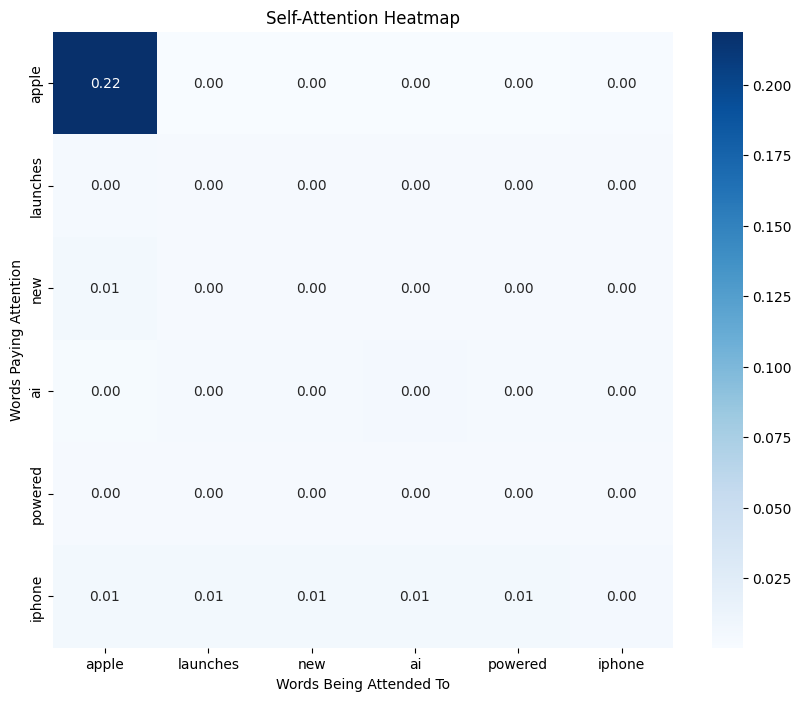

In [23]:
# ==========================================
# Task 8 - Attention Heatmap
# ==========================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------
# Example Text
# ------------------------------------------

sample_text = "Apple launches new AI powered iPhone"

sample_text = clean_text(sample_text)

words = sample_text.split()

# ------------------------------------------
# Tokenize
# ------------------------------------------

sequence = tokenizer.texts_to_sequences(
    [sample_text]
)

padded = pad_sequences(
    sequence,
    maxlen=MAX_LENGTH,
    padding='post'
)

# ------------------------------------------
# Get Attention Scores
# ------------------------------------------

prediction, attention_scores = (
    attention_score_model.predict(
        padded,
        verbose=0
    )
)

# Shape:
# (batch_size, num_heads, seq_len, seq_len)

attention_scores = attention_scores[0]

# ------------------------------------------
# Average Across Attention Heads
# ------------------------------------------

attention_matrix = np.mean(
    attention_scores,
    axis=0
)

# Keep only actual words
num_words = len(words)

attention_matrix = attention_matrix[
    :num_words,
    :num_words
]

# ------------------------------------------
# Convert to DataFrame
# ------------------------------------------

heatmap_df = pd.DataFrame(
    attention_matrix,
    index=words,
    columns=words
)

print(heatmap_df)

# ------------------------------------------
# Plot Heatmap
# ------------------------------------------

plt.figure(figsize=(10,8))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Self-Attention Heatmap")
plt.xlabel("Words Being Attended To")
plt.ylabel("Words Paying Attention")

plt.show()

# **Task 9: Save Model**
Save:
model.h5
tokenizer.pkl
label_encoder.pkl

In [26]:
# ==========================================
# Task 9 - Save Model
# ==========================================

import pickle

# ------------------------------------------
# Save Self-Attention Model
# ------------------------------------------

attention_model.save("model.h5")

print("Model saved as model.h5")

# ------------------------------------------
# Save Tokenizer
# ------------------------------------------

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved as tokenizer.pkl")

# ------------------------------------------
# Save Label Encoder
# ------------------------------------------

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Label Encoder saved as label_encoder.pkl")

print("\nAll files saved successfully!")

Model saved as model.h5
Tokenizer saved as tokenizer.pkl
Label Encoder saved as label_encoder.pkl

All files saved successfully!
